# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP
## LEVEL 2: Tasks 1, 2 and 3
### Dataset: Zomato Restaurant Dataset

This notebook covers:
- **Task 1:** Table Booking & Online Delivery
- **Task 2:** Price Range Analysis
- **Task 3:** Feature Engineering



## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Load Dataset

Keep `Dataset.csv` in the same folder as this notebook.

In [3]:
from pathlib import Path
import pandas as pd

# Current Jupyter Notebook folder
BASE_DIR = Path.cwd()
FILE = BASE_DIR / "Dataset.csv"

# Check file
if not FILE.exists():
    raise FileNotFoundError(
        f"Dataset.csv was not found in: {BASE_DIR}\n"
        "Please place Dataset.csv in the same folder as this notebook."
    )

# Load CSV with compatible encoding
df = pd.read_csv(FILE, encoding="latin1")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("File:", FILE)
print("Rows and columns:", df.shape)

print("\nOriginal columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED SUCCESSFULLY
File: c:\Internship\Cognifyz_Data_Science_Project\Level_2\Dataset.csv
Rows and columns: (9551, 27)

Original columns:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text', 'Votes', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']

First 5 rows:


,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Restaurant_Name_Length,Address_Length,Cuisine_Count,Has_Table_Booking_Encoded,Has_Online_Delivery_Encoded,Votes_per_Rating_Point
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,16,71,3,1,0,65.416667
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,16,67,1,1,0,131.333333
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,22,56,4,1,0,61.363636
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,4,70,2,0,0,74.489796
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,11,64,2,1,0,47.708333


## 3. Standardize Column Names

In [4]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(' ', '_')
      .str.replace('/', '_')
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
)

print('Standardized columns:')
print(df.columns.tolist())

Standardized columns:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text', 'Votes', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']


## 4. Basic Preprocessing

In [5]:
# Convert relevant columns to numeric
for col in ['Aggregate_rating', 'Votes', 'Price_range']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove duplicate rows
before = len(df)
df = df.drop_duplicates().copy()

print('Duplicate rows removed:', before - len(df))
print('Rows after preprocessing:', len(df))

print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('Missing_Values').head(15))

Duplicate rows removed: 0
Rows after preprocessing: 9551

Missing values:


,Missing_Values
Votes_per_Rating_Point,2148
Cuisines,9
Restaurant_Name,0
Country_Code,0
City,0
Locality,0
Address,0
Locality_Verbose,0
Longitude,0
Latitude,0


# TASK 1: TABLE BOOKING & ONLINE DELIVERY

In [6]:
print('=' * 60)
print('LEVEL 2 - TASK 1: TABLE BOOKING AND ONLINE DELIVERY')
print('=' * 60)

LEVEL 2 - TASK 1: TABLE BOOKING AND ONLINE DELIVERY


### 5. Table Booking Analysis

In [7]:
if 'Has_Table_booking' in df.columns:
    table_booking_pct = (
        df['Has_Table_booking'].value_counts(normalize=True) * 100
    ).round(2)

    print('Table booking percentage:')
    display(table_booking_pct.to_frame('Percentage'))

    if 'Aggregate_rating' in df.columns:
        table_avg = df.groupby('Has_Table_booking')['Aggregate_rating'].mean()
        print('Average rating by table booking:')
        display(table_avg.round(3).to_frame('Average_Rating'))
else:
    print('Has_Table_booking column not found.')

Table booking percentage:


,Percentage
Has_Table_booking,
No,87.88
Yes,12.12


Average rating by table booking:


,Average_Rating
Has_Table_booking,
No,2.559
Yes,3.442


### 6. Online Delivery Analysis

In [8]:
if 'Has_Online_delivery' in df.columns:
    delivery_pct = (
        df['Has_Online_delivery'].value_counts(normalize=True) * 100
    ).round(2)

    print('Online delivery percentage:')
    display(delivery_pct.to_frame('Percentage'))
else:
    print('Has_Online_delivery column not found.')

Online delivery percentage:


,Percentage
Has_Online_delivery,
No,74.34
Yes,25.66


### 7. Online Delivery by Price Range

Online delivery availability by price range (%):


Has_Online_delivery,No,Yes
Price_range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


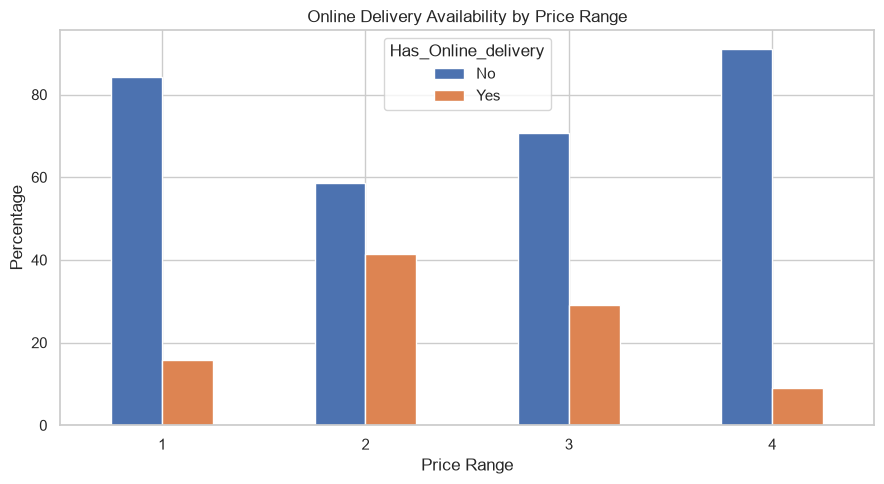

In [9]:
if {'Price_range', 'Has_Online_delivery'}.issubset(df.columns):
    delivery_by_price = pd.crosstab(
        df['Price_range'],
        df['Has_Online_delivery'],
        normalize='index'
    ) * 100

    print('Online delivery availability by price range (%):')
    display(delivery_by_price.round(2))

    delivery_by_price.plot(kind='bar', figsize=(9, 5))
    plt.title('Online Delivery Availability by Price Range')
    plt.xlabel('Price Range')
    plt.ylabel('Percentage')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Required columns for delivery-by-price analysis were not found.')

# TASK 2: PRICE RANGE ANALYSIS

In [10]:
print('=' * 60)
print('LEVEL 2 - TASK 2: PRICE RANGE ANALYSIS')
print('=' * 60)

LEVEL 2 - TASK 2: PRICE RANGE ANALYSIS


### 8. Most Common Price Range

In [11]:
if 'Price_range' in df.columns:
    common_price = df['Price_range'].mode()

    print('Most common price range:')
    print(common_price.iloc[0] if len(common_price) else 'Not available')

    price_counts = df['Price_range'].value_counts().sort_index()
    print('\nRestaurant count by price range:')
    display(price_counts.to_frame('Restaurant_Count'))
else:
    print('Price_range column not found.')

Most common price range:
1

Restaurant count by price range:


,Restaurant_Count
Price_range,
1,4444
2,3113
3,1408
4,586


### 9. Average Rating by Price Range

Average rating for each price range:


,Average_Rating
Price_range,
1,2.000
2,2.941
3,3.683
4,3.818


Highest average rating: Price Range 4 with average rating 3.818


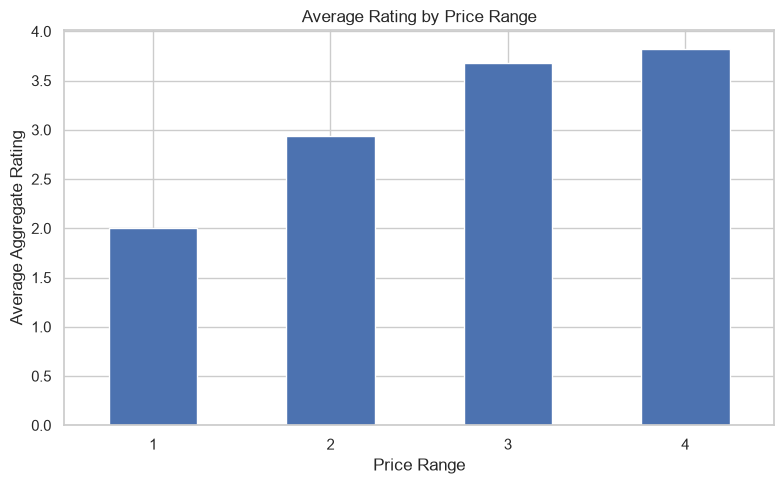

In [12]:
if {'Price_range', 'Aggregate_rating'}.issubset(df.columns):
    avg_rating_price = (
        df.groupby('Price_range')['Aggregate_rating']
        .mean()
        .sort_index()
    )

    print('Average rating for each price range:')
    display(avg_rating_price.round(3).to_frame('Average_Rating'))

    highest_price_rating = avg_rating_price.idxmax()
    highest_rating = avg_rating_price.max()

    print(
        f'Highest average rating: Price Range {highest_price_rating} '
        f'with average rating {highest_rating:.3f}'
    )

    plt.figure(figsize=(8, 5))
    avg_rating_price.plot(kind='bar')
    plt.title('Average Rating by Price Range')
    plt.xlabel('Price Range')
    plt.ylabel('Average Aggregate Rating')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Required columns for rating-by-price analysis were not found.')

# TASK 3: FEATURE ENGINEERING

In [13]:
print('=' * 60)
print('LEVEL 2 - TASK 3: FEATURE ENGINEERING')
print('=' * 60)

LEVEL 2 - TASK 3: FEATURE ENGINEERING


### 10. Create Restaurant Name Length

In [14]:
if 'Restaurant_Name' in df.columns:
    df['Restaurant_Name_Length'] = (
        df['Restaurant_Name'].fillna('').astype(str).str.len()
    )
    print('Restaurant_Name_Length created.')
else:
    print('Restaurant_Name column not found.')

Restaurant_Name_Length created.


### 11. Create Address Length

In [15]:
if 'Address' in df.columns:
    df['Address_Length'] = (
        df['Address'].fillna('').astype(str).str.len()
    )
    print('Address_Length created.')
else:
    print('Address column not found.')

Address_Length created.


### 12. Create Cuisine Count

In [16]:
if 'Cuisines' in df.columns:
    df['Cuisine_Count'] = (
        df['Cuisines']
        .fillna('')
        .astype(str)
        .apply(lambda x: len([c for c in x.split(',') if c.strip()]))
    )
    print('Cuisine_Count created.')
else:
    print('Cuisines column not found.')

Cuisine_Count created.


### 13. Binary Encoding: Table Booking and Online Delivery

In [17]:
binary_map = {
    'Yes': 1,
    'No': 0,
    'yes': 1,
    'no': 0
}

if 'Has_Table_booking' in df.columns:
    df['Has_Table_Booking_Encoded'] = df['Has_Table_booking'].map(binary_map)

if 'Has_Online_delivery' in df.columns:
    df['Has_Online_Delivery_Encoded'] = df['Has_Online_delivery'].map(binary_map)

print('Binary encoding completed.')

Binary encoding completed.


### 14. Create Votes per Rating Point

In [18]:
if {'Votes', 'Aggregate_rating'}.issubset(df.columns):
    df['Votes_per_Rating_Point'] = (
        df['Votes'] / df['Aggregate_rating'].replace(0, np.nan)
    )
    print('Votes_per_Rating_Point created.')
else:
    print('Votes or Aggregate_rating column not found.')

Votes_per_Rating_Point created.


### 15. Review Engineered Features

In [19]:
new_cols = [
    c for c in [
        'Restaurant_Name_Length',
        'Address_Length',
        'Cuisine_Count',
        'Has_Table_Booking_Encoded',
        'Has_Online_Delivery_Encoded',
        'Votes_per_Rating_Point'
    ] if c in df.columns
]

print('New engineered columns:')
print(new_cols)

print('\nSample of engineered data:')
display(df[new_cols].head())

print('\nData types after feature engineering:')
display(df[new_cols].dtypes.to_frame('Data_Type'))

New engineered columns:
['Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']

Sample of engineered data:


,Restaurant_Name_Length,Address_Length,Cuisine_Count,Has_Table_Booking_Encoded,Has_Online_Delivery_Encoded,Votes_per_Rating_Point
0,16,71,3,1,0,65.416667
1,16,67,1,1,0,131.333333
2,22,56,4,1,0,61.363636
3,4,70,2,0,0,74.489796
4,11,64,2,1,0,47.708333



Data types after feature engineering:


,Data_Type
Restaurant_Name_Length,int64
Address_Length,int64
Cuisine_Count,int64
Has_Table_Booking_Encoded,int64
Has_Online_Delivery_Encoded,int64
Votes_per_Rating_Point,float64


## 16. Save Engineered Dataset

In [20]:
OUTPUT_FILE = BASE_DIR / 'Level_2_Engineered_Dataset.csv'
df.to_csv(OUTPUT_FILE, index=False)

print('Saved successfully:')
print(OUTPUT_FILE)

Saved successfully:
c:\Internship\Cognifyz_Data_Science_Project\Level_2\Level_2_Engineered_Dataset.csv


# LEVEL 2 COMPLETE ✅

### Tasks completed
- Task 1: Table booking and online delivery analysis
- Task 2: Price range analysis
- Task 3: Feature engineering